# Day 17: Pre-class Assignment: Modeling with Ordinary Differential Equations

### <p style="text-align: right;"> &#9989; Put your name here</p>

### Goals for today's pre-class assignment
In this assignment, you will:

- Solve differential equations using `solve_ivp`
- Setup a *system* of differential equations (i.e., more than 1).


We will build off the previous assignment where we introduced using update equations to numerically integrate a (mathematical) function. Here we will expand our tool kit by numerically solving *multiple* differential equations simultaneously, and we'll solve them using a tool built into SciPy called `solve_ivp`. 

But first, let's talk about the role of differential equations in modeling.

___
## The Role of Differential Equations in Computational Modeling

We often use equations in computational modeling, and many of the systems we wish to model contain things that are **changing**:
* changing in time (E.g., Temperature or heart rate)
* changing in space (E.g., Temperature or elevation)
* changing strategies (E.g., deciding whether to invest)
* changing numbers (of people,  molecules, stars, etc.)
* changing prices
* and so on...

In mathematics, we describe change with calculus and derivatives in particular. When an equation has a derivative in it, it is called a "[differential equation](https://en.wikipedia.org/wiki/Differential_equation)" (as opposed to, say, an algebraic equation). The types of equations can be used to model many different systems, and in this assignment, we'll see how we can use them to model the free-fall of a skydiver.

&#9989;&nbsp; **Question**: What is a value or system that you deal with on a daily basis that is changing?

<font size=+3>&#9998;</font> *Put your answer here.*

---
## Revisiting update equations with the population growth model

In the last class, you used the update equations to approximate the population growth model:

\begin{equation}
\frac{dP}{dt} = kP\Big(1-\frac{P}{C}\Big),
\end{equation}

As a reminder, this is some example code for what that might have looked like:

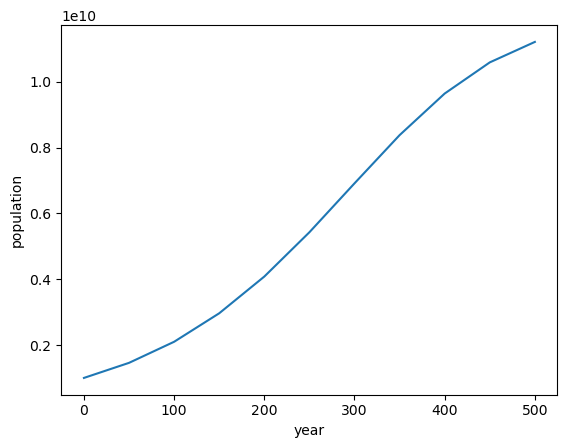

In [76]:
import numpy as np
import matplotlib.pyplot as plt

# define the derivative function
def deriv(P, k, C):
    dP_dt = k*P*(1-P/C)
    return dP_dt

# initial population
P0 = 1e9
# growth rate
k = 0.01
# carrying capacity
C = 12e9
# step size
dt = 50

# time
t = 0
# step size 
dt = 50

# lists to store data
pop_list = []
pop_list.append(P0)
year_list = []
year_list.append(t)


# current population
P_current = P0
# time loop
while t < 500:
    dPdt = deriv(P_current, k, C)
    P_new = P_current + dPdt*dt
    t += dt
    pop_list.append(P_new)
    year_list.append(t)
    P_current = P_new

# plot the results
plt.plot(year_list,pop_list) 
plt.xlabel('year')
plt.ylabel('population')
plt.show()

---
## Modeling the population growth model using `solve_ivp`

As with many computational models, there is often more than one way to find a solution. In fact, Python has a software library called SciPy that includes a tool for solving sets of differential questions called `solve_ivp`.

`solve_ivp` is a very powerful tool, but it can be a little tricky to use.  As with other tools we have learned in the class, we need to import `solve_ivp` before we use it.

In [59]:
# Import commands
from scipy.integrate import solve_ivp # This one is new to you!

**`solve_ivp` requires a few things from you in order to run.  These have to be in a very specific format in order to run correctly**:

1. A function that calculates the derivatives (slopes)
2. The desired start time and end time for your model
3. The initial value of your model
4. A list of times for which you want solutions

<img src="https://github.com/msu-cmse-courses/cmse201-supplemental/blob/main/Day-14/solve_ivp_structure.png?raw=true" alt="solve-ivp-structure" border="0" width=1200>

Let's walk through these, step by step!  We will look at the population growth model you looked at last class as an example.  Later in this assignment, you will code your own for a different system.  (The **[SciPy documentation for solve_ivp can be found here](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html).**)

### Run these cells!
The first thing we need is a ***function that calculates the derivatives***.  Run the cell below, and examine the code. 

In [72]:
# Adjusting the solution from Day 16 for solve_ivp
# We added time as the first input (required for solve_ivp)
# P_current is a placeholder that will be the value of the population model at the current time step

def population_deriv(time,P_current):
    P = P_current 
    # Define the differential equation for population
    dPdt = 0.01*P*(1-(P/1.2e10))
    return dPdt

**What about this function is similar to what you did in the previous class?  What is different?**

<font size=8 color="#009600">&#9998;</font> *Put your answer here*


In the cells below, we define the ***initial value*** for our population (1 billion) and our ***start and end times*** (year 0 and year 500) for the model.  We also define an ***array of time values*** that includes every year between our start and end time.

In [67]:
# initial value of the population as a list! Note: The list format is required for solve_ivp
P0 = [1.0e9]
# define a start time and end time for the model
t_min = 0
t_max = 500
# create an array of time values
t_vals = np.linspace(t_min,t_max,501)

Now, we are ready to call `solve_ivp`.  Note where we include each of the requirements as an argument for the `solve_ivp` function!

In [75]:
# Run a solve_ivp call and save it as a variable so you can get the results later!
sol = solve_ivp(population_deriv,(t_min,t_max),P0,t_eval = t_vals)

#### Run the cell below!
This is an example of "unpacking" the modeled values calculated by `solve_ivp` for plotting (and then plotting them). 

Text(0, 0.5, 'Population')

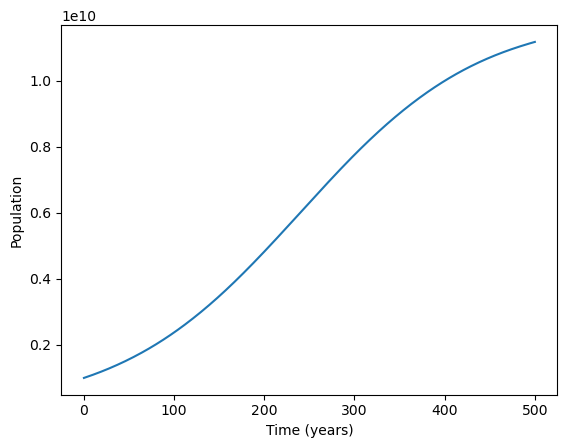

In [77]:
# Unpack the solution for plotting!
time_array = sol.t
population_solution = sol.y[0,:]

# plot your solution!
plt.plot(sol.t,sol.y[0,:])
plt.xlabel('Time (years)')
plt.ylabel('Population')
plt.show()

**Make a plot that includes the results from the update equations and the results from `solve_ivp`**.  Remember to include axis labels, and label each curve in the plot.

In [ ]:
# put your code here!

# Do not delete this line!
plt.savefig()

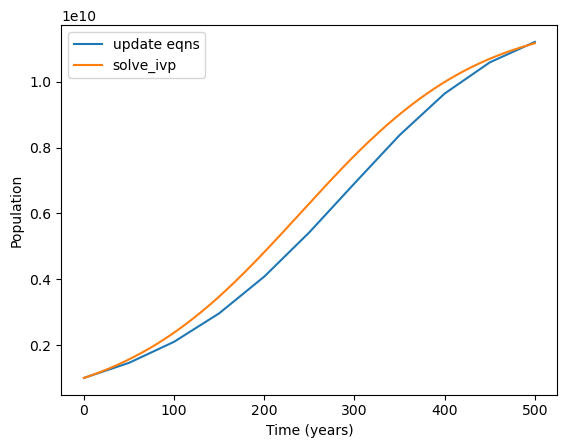

In [116]:
### ANSWER
plt.plot(year_list,pop_list, label='update eqns') 
plt.plot(sol.t,sol.y[0,:], label='solve_ivp')
plt.xlabel('Time (years)')
plt.ylabel('Population')
plt.legend()
plt.show()

How do the results compare? What might be different about the methods above that could be causing some of the differences?

<font size=8 color="#009600">&#9998;</font> *Put your answer here*

---
## Using `solve_ivp` with a different system (your turn!)

<img src="https://tikz.net/wp-content/uploads/2022/02/dynamics_spring-003.png" width= 400><p style="text-align: right;">
</p>

<img src="https://tikz.net/wp-content/uploads/2022/02/dynamics_spring-002.png" width= 400><p style="text-align: right;">
</p>

<img src="https://tikz.net/wp-content/uploads/2022/02/dynamics_spring-004.png" width= 400><p style="text-align: right;">
</p>

This time, you will write some code yourself.  (Don't worry, we provide some of the code to help you!) We will model a mass on a spring, which will oscillate back and forth.  The system can be modeled by

$$\frac{dx}{dt} = v$$

$$\frac{dv}{dt} = -\frac{kx}{m}$$

Here, the variables are:
* $x$ is displacement of the mass from equilibrium,
* $v$ is velocity of the mass,
* $k$ is the spring constant,
* $m$ is the mass.

&#9989;&nbsp; The first step is to define a function to calculate the derivatives.  **Review each line of the code below, and add comments or fill in the blanks as indicated.**

For this problem, use $k=1.6$ and $m=0.5$

In [38]:
# Derivative function
def derivs(time,curr_vals):

    # Declare parameters
    m = ???   # <----- FILL THIS LINE IN! 
    k = ???   # <----- FILL THIS LINE IN!
    
    x, v = curr_vals # What do you think this line is doing???
    
    # Right-hand side of odes, which are used to compute the derivative
    dxdt = ???  # <----- FILL THIS LINE IN! 
    dvdt = ???  # <----- FILL THIS LINE IN!
    
    return dxdt, dvdt

In [38]:
### ANSWER

# Derivative function
def derivs(time,curr_vals):

    # Declare parameters
    m = 0.5   # <----- FILL THIS LINE IN! 
    k = 1.6   # <----- FILL THIS LINE IN!
    
    x, v = curr_vals # What do you think this line is doing???
    
    # Right-hand side of odes, which are used to compute the derivative
    dxdt = v  # <----- FILL THIS LINE IN! 
    dvdt = -k*x/m  # <----- FILL THIS LINE IN!
    
    return dxdt, dvdt

&#9989;&nbsp; Now we need to set initial values and determine the step size for our problem.  **Review each line of the code below, and add comments or fill in the blanks as indicated.**

For this problem, use $x_0=2.1$ and $v_0=-3.2$ for initial conditions.  Simulate the system for a time of 5, starting at 0, with a step size $dt$ of 0.1.

In [71]:
# Declare Variables for initial conditions
x0 = ???  # <----- FILL THIS LINE IN! 
v0 = ??? # <----- FILL THIS LINE IN! 

# set 
tmin = 0 
tmax = ??? # <----- FILL THIS LINE IN! 
dt = ???   # <----- FILL THIS LINE IN! 

time = np.arange(tmin, tmax + dt, dt) # What do you think this line is doing???

In [71]:
### ANSWER

# Declare Variables for initial conditions
x0 = 2.1  # <----- FILL THIS LINE IN! 
v0 = -3.2 # <----- FILL THIS LINE IN! 

# set 
tmin = 0 
tmax = 5 # <----- FILL THIS LINE IN! 
dt = 0.1 # <----- FILL THIS LINE IN! 

time = np.arange(tmin, tmax + dt, dt) # What do you think this line is doing???

&#9989;&nbsp; Now we just call `solve_ivp` and plot the results.  The code for this is given for you.  **Run the cell below, and make sure you understand what the code is doing.**

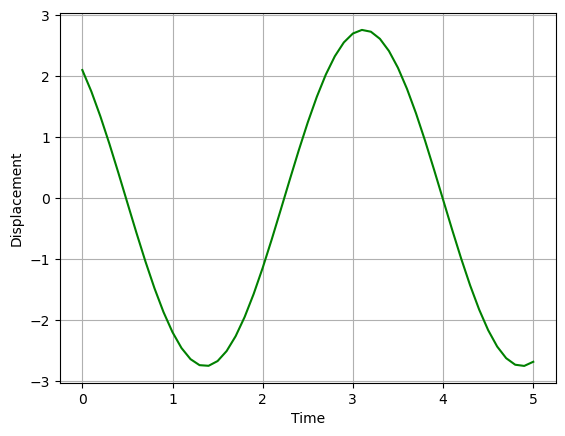

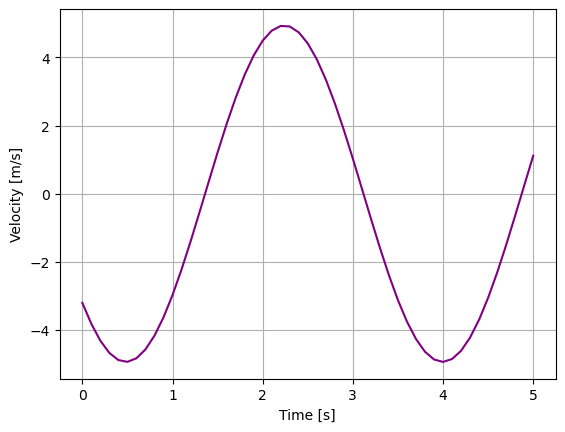

In [78]:
# Store the initial values in a list
init = [x0, v0]

# Solve the odes with solve_ivp
sol = solve_ivp(derivs,(tmin,tmax),init,t_eval = time)


# Plot the results using the values stored in the solution variable, "sol"

# Plot the displacement using the "0" element from the solution
plt.figure(1)
plt.plot(time, sol.y[0,:],color="green")
plt.xlabel('Time')
plt.ylabel('Displacement')
plt.grid()

# Plot the velocity using the "1" element from the solution
plt.figure(2)
plt.plot(time, sol.y[1,:],color="purple")
plt.xlabel('Time [s]')
plt.ylabel('Velocity [m/s]')
plt.grid()

&#9989;&nbsp; **Try changing some of the parameters (for example, $m$, $k$, initial conditions, step size $dt$).  What do you observe?**

<font size=+3>&#9998;</font> *Put your answer here.*

&#9989;&nbsp; **In your own words, describe what the variable `curr_vals` holds? You may need use the `solve_ivp` documentation mentioned above.**

<font size=+3>&#9998;</font> *Put your answer here.*

&#9989;&nbsp; **Try changing the order of the arguments in the function (I.e., `curr_vals` and `time`). Does it still work?**

<font size=+3>&#9998;</font> *Put your answer here.*

---
### Assignment wrapup

Please fill out the form that appears when you run the code below.  **You must completely fill this out in order to receive credit for the assignment!**

from IPython.display import HTML
HTML(
"""
<iframe 
	src="https://cmse.msu.edu/cmse201-pc-survey" 
	width="800px" 
	height="600px" 
	frameborder="0" 
	marginheight="0" 
	marginwidth="0">
	Loading...
</iframe>
"""
)

### Congratulations, you're done!

Submit this assignment by uploading it to the course D2L web page.  Go to the "Pre-class assignments" folder, find the appropriate submission link, and upload it there.

See you in class!

&#169; Copyright 2025,  Michigan State University Board of Trustees